<a href="https://colab.research.google.com/github/smartanilmali234-art/Anilmali/blob/main/Week3_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction using Machine Learning
### Week 3 – Machine Learning Fundamentals
### Name: Anil Mali

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [41]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
print(df.shape)

df.info()

df.describe(include="all")

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [43]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
# Remove unnecessary column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [45]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


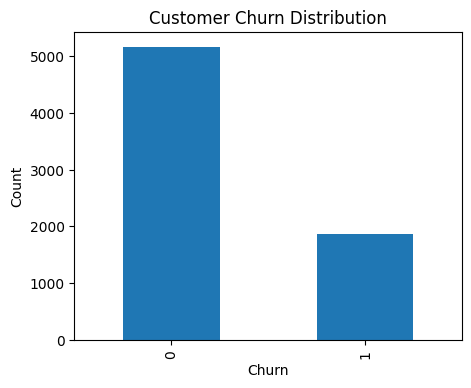

In [46]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

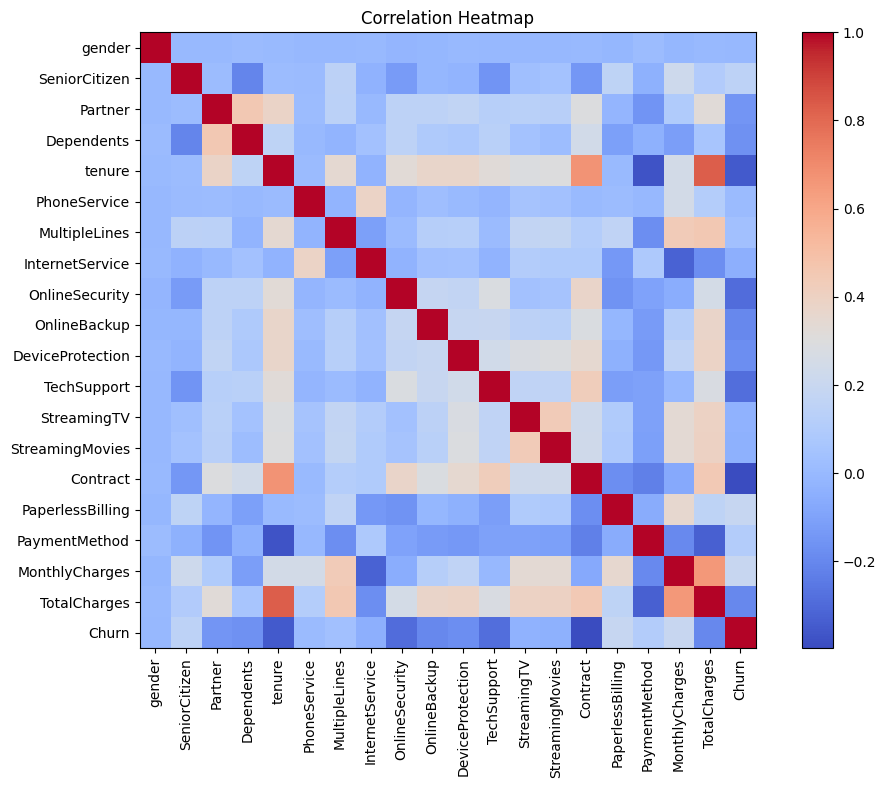

In [47]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap")

plt.show()

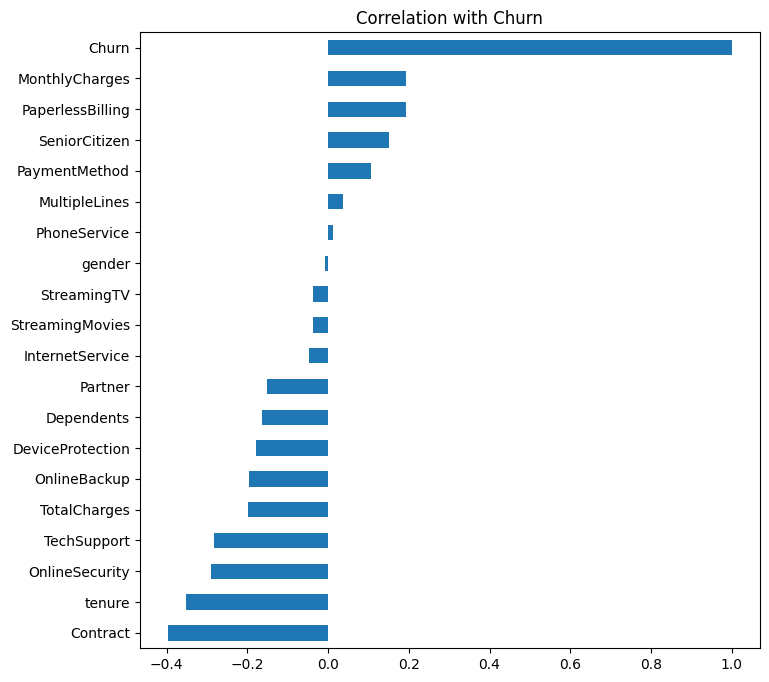

In [48]:
corr["Churn"].sort_values().plot(
    kind="barh",
    figsize=(8,8)
)

plt.title("Correlation with Churn")

plt.show()

In [49]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

In [52]:
print("Decision Tree Accuracy")

print(accuracy_score(
    y_test,
    tree_pred
))

print()

print(classification_report(
    y_test,
    tree_pred
))

Decision Tree Accuracy
0.7849538679914834

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



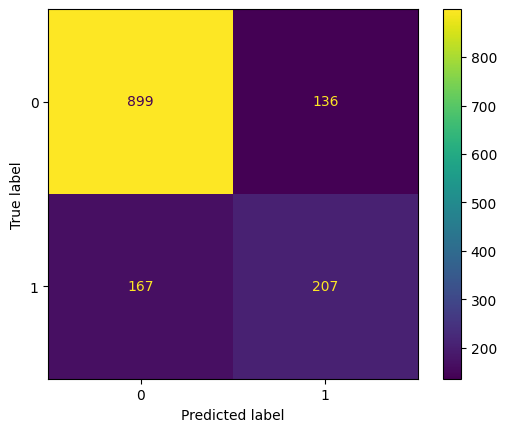

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred
)

plt.show()

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

In [55]:
print("Logistic Regression Accuracy")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

print()

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy
0.7991483321504613

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



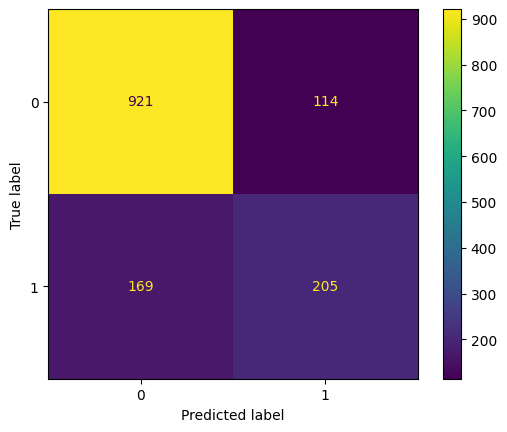

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.show()

In [57]:
tree_acc = accuracy_score(
    y_test,
    tree_pred
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Decision Tree :", tree_acc)

print("Logistic Regression :", lr_acc)

Decision Tree : 0.7849538679914834
Logistic Regression : 0.7991483321504613


In [58]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tree.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
14,Contract,0.525341
8,OnlineSecurity,0.138973
4,tenure,0.099174
7,InternetService,0.091187
18,TotalCharges,0.060525
17,MonthlyCharges,0.057434
16,PaymentMethod,0.018331
1,SeniorCitizen,0.006759
11,TechSupport,0.002142
9,OnlineBackup,0.000135


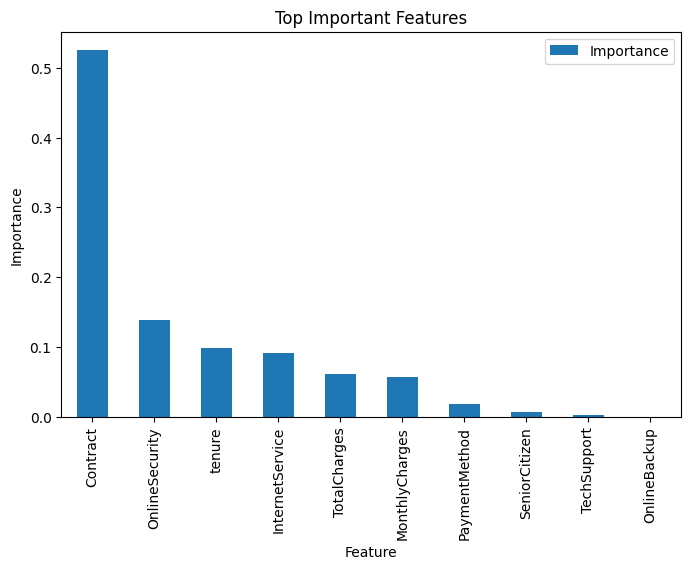

In [59]:
importance.head(10).plot(

    x="Feature",

    y="Importance",

    kind="bar",

    figsize=(8,5)

)

plt.title("Top Important Features")

plt.ylabel("Importance")

plt.show()

In [60]:
print(importance.head(3))

           Feature  Importance
14        Contract    0.525341
8   OnlineSecurity    0.138973
4           tenure    0.099174


In [61]:
print(df["Churn"].value_counts())

print()

print(df["Churn"].value_counts(normalize=True))

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


The dataset has a moderate class imbalance, with significantly more customers who did not churn than those who churned. This imbalance can affect model performance, especially for the minority class. In this assignment, the imbalance is identified and reported. Future improvements could include techniques such as class weights, oversampling (SMOTE), or undersampling.

#Business Summary

This project predicts which customers are likely to leave the company. Analysis indicates that factors such as contract type, tenure, and monthly charges strongly influence customer churn. The Decision Tree model highlights the most important features driving churn, while Logistic Regression provides a reliable baseline for comparison. These insights can help the business identify at-risk customers early and take proactive retention measures, reducing customer loss and improving long-term revenue.

#Conclusion

This project demonstrates how machine learning can be applied to solve a real business problem. After cleaning the data, encoding categorical variables, and comparing Decision Tree and Logistic Regression models, the results showed that customer churn can be predicted with good accuracy. Feature importance analysis identified the main factors influencing churn, providing actionable insights for business decision-making.